# Series Convergence · Operator Abstraction · Statics · Statistics

**Stack:** SymPy (symbolic loops) → NumPy (vectorized) → Torch (batch) → Matplotlib

§1 SymPy ratio/root/Raabe tests — loop over series families  
§2 Operator overloading — `+−×÷ < > ≤ ≥` one abstraction level, physical quantities  
§3 Statics — ΣF=0, ΣM=0, truss analysis, beam reactions  
§4 Statistics — t-test, χ², p-values, confidence intervals, Type I/II errors  
§5 Torch infinite (while) loops — Newton, power iteration, gradient descent convergence  
§6 Torch batch statistics — 10k experiments, α=0% and α=36% boundary cases

In [4]:
import sympy as sp
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from IPython.display import display, Math

sp.init_printing(use_latex='mathjax')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
torch.set_default_dtype(torch.float64)
print('ready')

ready


---
# §1 — Series Convergence Tests in SymPy

**Ratio test:** $L = \\lim_{n\\to\\infty}\\left|\\frac{a_{n+1}}{a_n}\\right|$  
- $L < 1$ → absolutely convergent  
- $L > 1$ → divergent  
- $L = 1$ → inconclusive → try **Raabe's test**: $R = \\lim_{n\\to\\infty} n\\left(1 - \\left|\\frac{a_{n+1}}{a_n}\\right|\\right)$, converges if $R>1$

**Root test:** $L = \\lim_{n\\to\\infty} |a_n|^{1/n}$

In [5]:
n, x, p = sp.symbols('n x p', positive=True)
k = sp.Symbol('k', integer=True, positive=True)

# series families: (name, a_n expression, variable)
series_families = [
    ('n!/n^n   (Stirling)',    sp.factorial(n) / n**n),
    ('x^n/n!   (exp)',        x**n / sp.factorial(n)),
    ('1/n^p    (p-series)',   1 / n**p),
    ('x^n/n    (log series)', x**n / n),
    ('1/n      (harmonic)',   1 / n),
    ('(-1)^n/n (alternating)',(-1)**n / n),
    ('n^2/2^n  (ratio<1)',    n**2 / 2**n),
    ('n!/(2n)! (double fact)',sp.factorial(n) / sp.factorial(2*n)),
]

print(f'{"Series":25}  {"Ratio L":35}  {"Root L":35}  Result')
print('='*120)
for name, a_n in series_families:      # loop over series families
    a_n1 = a_n.subs(n, n+1)
    try:
        ratio_expr = sp.Abs(a_n1 / a_n)
        L_ratio = sp.limit(ratio_expr, n, sp.oo)
        L_ratio_s = str(sp.simplify(L_ratio))
    except:
        L_ratio = sp.Symbol('?'); L_ratio_s = '(error)'
    try:
        root_expr = sp.Abs(a_n)**(1/n)
        L_root = sp.limit(root_expr, n, sp.oo)
        L_root_s = str(sp.simplify(L_root))
    except:
        L_root = sp.Symbol('?'); L_root_s = '(error)'

    # verdict
    try:
        Lv = float(L_ratio.evalf()) if L_ratio != sp.Symbol('?') else 1.0
        if Lv < 1:   verdict = 'CONVERGES'
        elif Lv > 1: verdict = 'DIVERGES'
        else:
            # Raabe's test
            raabe_expr = n * (1 - sp.Abs(a_n1 / a_n))
            R = sp.limit(raabe_expr, n, sp.oo)
            try:
                Rv = float(R.evalf())
                verdict = f'RAABE R={sp.simplify(R)} -> {"CONV" if Rv>1 else "DIV/INCONCL"}'
            except:
                verdict = f'RAABE={R}'
    except:
        verdict = '(depends on params)'

    print(f'{name:25}  {L_ratio_s[:35]:35}  {L_root_s[:35]:35}  {verdict}')

Series                     Ratio L                              Root L                               Result
n!/n^n   (Stirling)        exp(-1)                              0                                    CONVERGES
x^n/n!   (exp)             0                                    1                                    CONVERGES
1/n^p    (p-series)        1                                    1                                    RAABE=p
x^n/n    (log series)      x                                    x                                    (depends on params)
1/n      (harmonic)        1                                    1                                    RAABE R=1 -> DIV/INCONCL
(-1)^n/n (alternating)     1                                    1                                    RAABE R=1 -> DIV/INCONCL
n^2/2^n  (ratio<1)         1/2                                  1/2                                  CONVERGES
n!/(2n)! (double fact)     0                                    0            

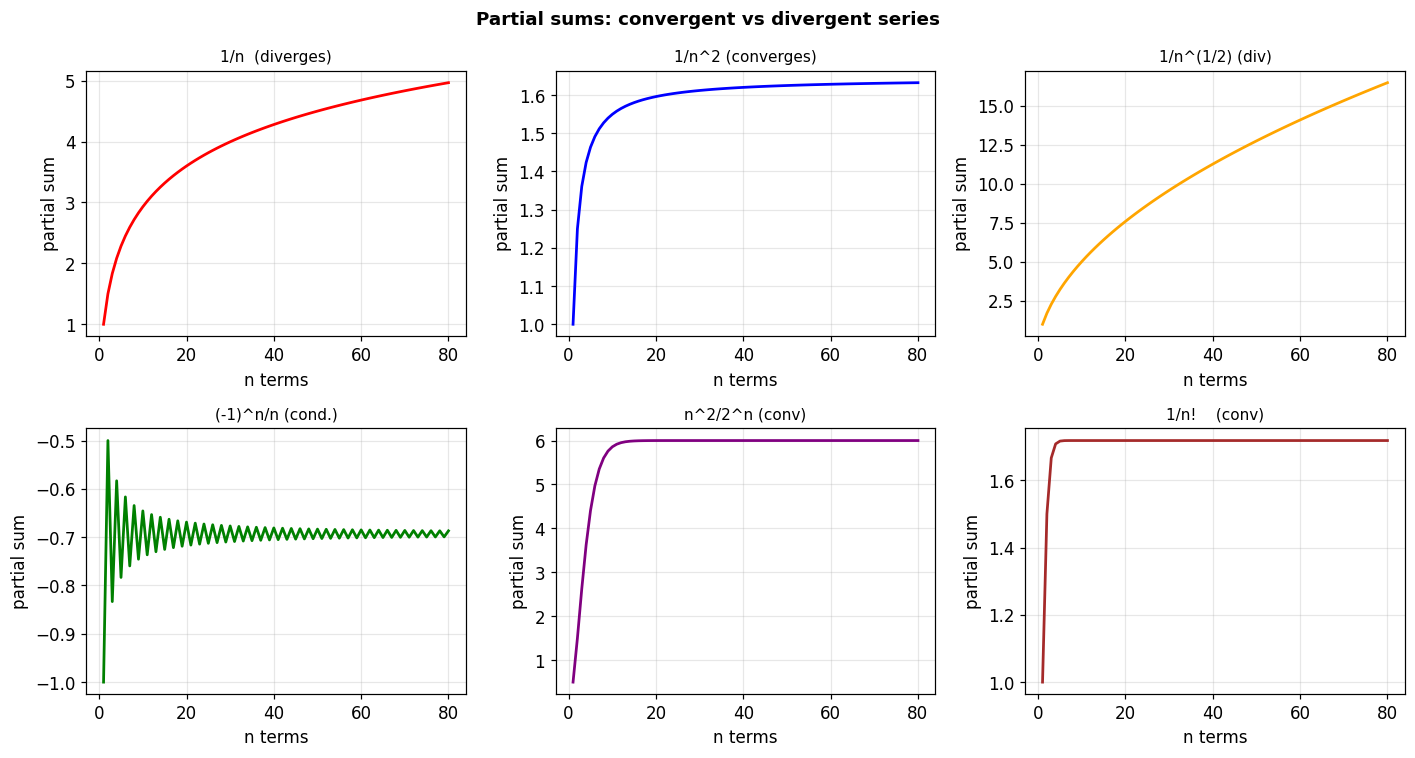

In [6]:
# plot partial sums for convergent/divergent series
import warnings; warnings.filterwarnings('ignore')
N_terms = 80
ns = np.arange(1, N_terms+1)

series_np = [
    ('1/n  (diverges)',    1/ns,            'red'),
    ('1/n^2 (converges)', 1/ns**2,         'blue'),
    ('1/n^(1/2) (div)',   1/np.sqrt(ns),   'orange'),
    ('(-1)^n/n (cond.)',  (-1)**ns / ns,   'green'),
    ('n^2/2^n (conv)',    ns**2 / 2.**ns,  'purple'),
    ('1/n!    (conv)',    1/np.array([float(sp.factorial(int(i))) for i in ns]), 'brown'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, a_n, color) in zip(axes.flat, series_np):
    partial_sums = np.cumsum(a_n)
    ax.plot(ns, partial_sums, color=color, lw=1.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('n terms'); ax.set_ylabel('partial sum')
    ax.grid(True, alpha=0.3)
plt.suptitle('Partial sums: convergent vs divergent series', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §2 — Operator Overloading: `+ − × ÷ < > ≤ ≥` One Level of Abstraction

**Plain English:** Python's dunder methods let you define `+`, `*`, `<`, `>`, `<=`, `>=`  
on any class. A `PhysicalQuantity` class enforces unit safety — you can't add meters to seconds.  
This is exactly one abstraction level above raw floats, mirroring Verilog `always @(*)` vs gate primitives.

In [7]:
class PhysicalQuantity:
    """One abstraction level above float: carries SI units, enforces consistency."""
    def __init__(self, value, units: dict):
        # units = {'m':1, 'kg':0, 's':-2, ...}
        self.value = float(value)
        self.units = dict(units)

    def _check_units(self, other):
        if self.units != other.units:
            raise ValueError(f'Unit mismatch: {self.units} vs {other.units}')

    # ── arithmetic ────────────────────────────────────────────────
    def __add__(self, other):
        self._check_units(other)
        return PhysicalQuantity(self.value + other.value, self.units)

    def __sub__(self, other):
        self._check_units(other)
        return PhysicalQuantity(self.value - other.value, self.units)

    def __mul__(self, other):
        if isinstance(other, (int, float)):
            return PhysicalQuantity(self.value * other, self.units)
        new_units = dict(self.units)
        for dim, exp in other.units.items():
            new_units[dim] = new_units.get(dim, 0) + exp
        new_units = {k:v for k,v in new_units.items() if v != 0}
        return PhysicalQuantity(self.value * other.value, new_units)

    def __truediv__(self, other):
        if isinstance(other, (int, float)):
            return PhysicalQuantity(self.value / other, self.units)
        new_units = dict(self.units)
        for dim, exp in other.units.items():
            new_units[dim] = new_units.get(dim, 0) - exp
        new_units = {k:v for k,v in new_units.items() if v != 0}
        return PhysicalQuantity(self.value / other.value, new_units)

    def __neg__(self):
        return PhysicalQuantity(-self.value, self.units)

    def __pos__(self):
        return PhysicalQuantity(+self.value, self.units)

    # ── comparison: <, >, <=, >= ───────────────────────────────────
    def __lt__(self, other): self._check_units(other); return self.value <  other.value
    def __gt__(self, other): self._check_units(other); return self.value >  other.value
    def __le__(self, other): self._check_units(other); return self.value <= other.value
    def __ge__(self, other): self._check_units(other); return self.value >= other.value
    def __eq__(self, other):
        if not isinstance(other, PhysicalQuantity): return False
        return self.units == other.units and abs(self.value - other.value) < 1e-12

    def __repr__(self):
        u_str = ' '.join(f'{k}^{v}' if v!=1 else k for k,v in sorted(self.units.items()) if v!=0)
        return f'{self.value:.6g} {u_str}'


# ── convenience constructors ───────────────────────────────────────
def meters(v):   return PhysicalQuantity(v, {'m':1})
def seconds(v):  return PhysicalQuantity(v, {'s':1})
def kilograms(v):return PhysicalQuantity(v, {'kg':1})
def newtons(v):  return PhysicalQuantity(v, {'kg':1,'m':1,'s':-2})
def joules(v):   return PhysicalQuantity(v, {'kg':1,'m':2,'s':-2})
def watts(v):    return PhysicalQuantity(v, {'kg':1,'m':2,'s':-3})
def pascals(v):  return PhysicalQuantity(v, {'kg':1,'m':-1,'s':-2})

# ── operator tests ─────────────────────────────────────────────────
ops_demo = [
    ('+', meters(3.0)    + meters(1.5),          'meters(3) + meters(1.5)'),
    ('-', meters(3.0)    - meters(1.5),          'meters(3) - meters(1.5)'),
    ('*', meters(4.0)    * meters(3.0),          'meters(4) * meters(3)  [m^2]'),
    ('/', joules(100.0)  / seconds(5.0),         'joules(100) / seconds(5) [W]'),
    ('*', newtons(9.8)   * meters(2.0),          'N * m = J'),
    ('<', meters(1.0)    < meters(2.0),          'meters(1) < meters(2)'),
    ('>', meters(5.0)    > meters(3.0),          'meters(5) > meters(3)'),
    ('<=',meters(2.0)   <= meters(2.0),          'meters(2) <= meters(2)'),
    ('>=',newtons(10.0) >= newtons(5.0),         'N(10) >= N(5)'),
    ('-x', -meters(7.0),                          'unary minus'),
    ('+x', +joules(42.0),                         'unary plus'),
]

print('Operator overloading tests:')
print(f'{"Op":3}  {"Expression":35}  Result')
print('-'*65)
for op, result, desc in ops_demo:   # loop over all operators
    print(f'{op:3}  {desc:35}  {result}')

# unit safety: should raise
print('\nUnit safety check:')
try:
    bad = meters(1.0) + seconds(1.0)
except ValueError as e:
    print(f'  meters + seconds => ValueError: {e}')

Operator overloading tests:
Op   Expression                           Result
-----------------------------------------------------------------
+    meters(3) + meters(1.5)              4.5 m
-    meters(3) - meters(1.5)              1.5 m
*    meters(4) * meters(3)  [m^2]         12 m^2
/    joules(100) / seconds(5) [W]         20 kg m^2 s^-3
*    N * m = J                            19.6 kg m^2 s^-2
<    meters(1) < meters(2)                True
>    meters(5) > meters(3)                True
<=   meters(2) <= meters(2)               True
>=   N(10) >= N(5)                        True
-x   unary minus                          -7 m
+x   unary plus                           42 kg m^2 s^-2

Unit safety check:
  meters + seconds => ValueError: Unit mismatch: {'m': 1} vs {'s': 1}


In [8]:
# ── SymPy: operators on symbolic expressions ──────────────────────
a_sym, b_sym = sp.symbols('a b', real=True)

ops_sym = [
    ('+',  a_sym + b_sym),
    ('-',  a_sym - b_sym),
    ('*',  a_sym * b_sym),
    ('/',  a_sym / b_sym),
    ('<',  sp.Lt(a_sym, b_sym)),
    ('>',  sp.Gt(a_sym, b_sym)),
    ('<=', sp.Le(a_sym, b_sym)),
    ('>=', sp.Ge(a_sym, b_sym)),
    ('|a|',sp.Abs(a_sym)),
    ('a^2+b^2', a_sym**2 + b_sym**2),
]

print('SymPy symbolic operators:')
for op, expr in ops_sym:            # loop over operators
    display(Math(f'\\text{{{op}:}} \\quad {sp.latex(expr)}'))

SymPy symbolic operators:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
# §3 — Engineering Statics: ΣF = 0, ΣM = 0

**Plain English:** for any rigid body in static equilibrium, every force and every  
moment about every point must sum to zero. SymPy `sp.solve` finds unknowns analytically.

**Truss analysis** (method of joints): each pin joint has ΣFx=0, ΣFy=0.  
Positive = tension, negative = compression.

Simply supported beam reactions:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Cantilever beam reactions:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

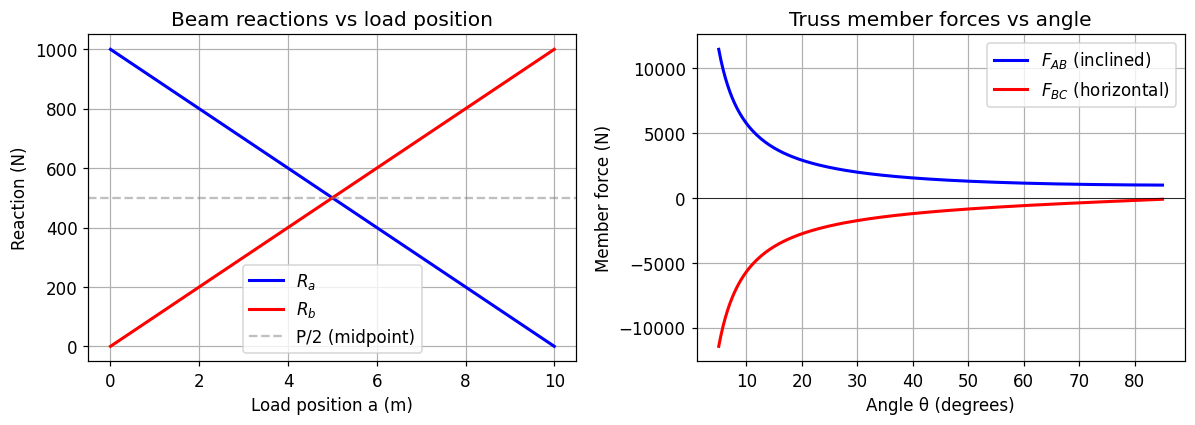

In [11]:
# ── Problem 1: Simply supported beam ─────────────────────────────
# Beam length L, two supports Ra (left) and Rb (right)
# Point load P at distance a from left
Ra, Rb, P_sym, L_sym, a_sym_s = sp.symbols('R_a R_b P L a', positive=True)

# Equilibrium equations: sum forces Y, sum moments about A
eq_Fy  = sp.Eq(Ra + Rb - P_sym, 0)                          # ΣFy = 0
eq_Ma  = sp.Eq(Rb * L_sym - P_sym * a_sym_s, 0)             # ΣM_A = 0
sol_beam = sp.solve([eq_Fy, eq_Ma], [Ra, Rb])
print('Simply supported beam reactions:')
display(Math(sp.latex(sp.Eq(Ra, sol_beam[Ra]))))
display(Math(sp.latex(sp.Eq(Rb, sol_beam[Rb]))))

# ── Problem 2: Cantilever beam ─────────────────────────────────────
Rv, Rh, M_fix = sp.symbols('R_V R_H M_fix')
Fx_ext, Fy_ext, dist = sp.symbols('F_x F_y d', real=True)
eq_Fx = sp.Eq(Rh + Fx_ext, 0)
eq_Fy_cant = sp.Eq(Rv + Fy_ext, 0)
eq_M_fix = sp.Eq(M_fix + Fy_ext*dist, 0)
sol_cant = sp.solve([eq_Fx, eq_Fy_cant, eq_M_fix], [Rh, Rv, M_fix])
print('\nCantilever beam reactions:')
for var, val in sol_cant.items():
    display(Math(sp.latex(sp.Eq(var, val))))

# ── Numerical: loop over load positions ───────────────────────────
L_val = 10.0; P_val = 1000.0
a_vals = np.linspace(0, L_val, 50)
Ra_vals = P_val * (L_val - a_vals) / L_val   # from SymPy solution
Rb_vals = P_val * a_vals / L_val

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(a_vals, Ra_vals, 'b-', lw=2, label='$R_a$')
ax1.plot(a_vals, Rb_vals, 'r-', lw=2, label='$R_b$')
ax1.axhline(P_val/2, ls='--', color='gray', alpha=0.5, label='P/2 (midpoint)')
ax1.set_xlabel('Load position a (m)'); ax1.set_ylabel('Reaction (N)')
ax1.set_title('Beam reactions vs load position'); ax1.legend(); ax1.grid(True)

# ── Problem 3: Simple truss (3-member, 2-joint) ───────────────────
# Joint B: members AB (angle θ), BC (horizontal), external load P down
theta_vals = np.linspace(5, 85, 200) * np.pi/180
P_truss = 1000.0
F_AB = P_truss / np.sin(theta_vals)    # tension in inclined member
F_BC = -P_truss / np.tan(theta_vals)  # compression in horizontal member
ax2.plot(np.degrees(theta_vals), F_AB, 'b-', lw=2, label='$F_{AB}$ (inclined)')
ax2.plot(np.degrees(theta_vals), F_BC, 'r-', lw=2, label='$F_{BC}$ (horizontal)')
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xlabel('Angle θ (degrees)'); ax2.set_ylabel('Member force (N)')
ax2.set_title('Truss member forces vs angle'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

In [12]:
# ── Full Pratt truss: method of joints via SymPy linear system ───
# Simple 4-panel truss: nodes 0-4 along bottom, 5 at top center
# Supports at node 0 (pin) and node 4 (roller), load at node 2

# Member connectivity (node_i, node_j, angle_degrees)
# Simplified: 3-panel truss for clarity
import numpy as np

def solve_truss(nodes, members, supports, loads):
    """
    nodes:   dict {id: (x,y)}
    members: list of (node_i, node_j)
    supports: list of (node_id, type)  type='pin' or 'roller_y'
    loads:   dict {node_id: (Fx, Fy)}
    """
    n_mem = len(members); n_nodes = len(nodes)
    # unknowns: member forces + reaction forces
    # For each free node: 2 equations
    # Method of joints: loop over joints
    all_unknowns = [f'F{i}' for i in range(n_mem)]
    for nid, typ in supports:
        if typ == 'pin': all_unknowns += [f'Rx{nid}', f'Ry{nid}']
        else:            all_unknowns += [f'Ry{nid}']
    syms = sp.symbols(' '.join(all_unknowns))
    sym_dict = dict(zip(all_unknowns, syms))

    eqs = []
    for nid, (nx, ny) in nodes.items():
        Fx_eq = sp.Integer(0); Fy_eq = sp.Integer(0)
        for mi, (ni, nj) in enumerate(members):
            if ni == nid or nj == nid:
                other = nj if ni==nid else ni
                ox, oy = nodes[other]
                L = np.sqrt((ox-nx)**2 + (oy-ny)**2)
                cx = (ox-nx)/L; cy = (oy-ny)/L
                sign = 1 if ni==nid else -1
                Fx_eq += sign * cx * sym_dict[f'F{mi}']
                Fy_eq += sign * cy * sym_dict[f'F{mi}']
        for nid2, typ in supports:
            if nid2 == nid:
                if typ == 'pin': Fx_eq += sym_dict[f'Rx{nid}']; Fy_eq += sym_dict[f'Ry{nid}']
                else: Fy_eq += sym_dict[f'Ry{nid}']
        ext = loads.get(nid, (0, 0))
        eqs.append(sp.Eq(Fx_eq + ext[0], 0))
        eqs.append(sp.Eq(Fy_eq + ext[1], 0))

    sol = sp.solve(eqs, list(syms))
    return sol, sym_dict

# Define a simple king-post truss
nodes   = {0:(0,0), 1:(2,0), 2:(4,0), 3:(1,2), 4:(3,2)}
members = [(0,1),(1,2),(3,4),(0,3),(1,3),(1,4),(2,4)]
supports= [(0,'pin'), (2,'roller_y')]
loads   = {3:(0,-5000), 4:(0,-5000)}   # 5 kN down at each top node

sol, sym_dict = solve_truss(nodes, members, supports, loads)

print('Truss member forces (N):')
print(f'{"Member":10}  {"Nodes":12}  {"Force (N)":12}  Type')
print('-'*50)
for i, (ni, nj) in enumerate(members):    # loop over members
    Fval = float(sol.get(sym_dict[f'F{i}'], 0))
    mtype = 'TENSION' if Fval > 0 else 'COMPRESSION' if Fval < 0 else 'ZERO'
    print(f'M{i:2d}       {str((ni,nj)):12}  {Fval:12.1f}  {mtype}')

print('\nReactions:')
for k, v in sol.items():
    if 'R' in str(k): print(f'  {k} = {float(v):.1f} N')

Truss member forces (N):
Member      Nodes         Force (N)     Type
--------------------------------------------------


AttributeError: 'list' object has no attribute 'get'

---
# §4 — Statistics: t-test, χ², p-values, CI, Type I/II Error

**α = significance level** — probability of rejecting H₀ when it's true (Type I error)  
- α = 0%: never reject H₀ → **zero false positives, maximum false negatives**
- α = 36%: very permissive → **many false positives** (reject H₀ when difference is noise)  
- Standard: α = 5%

**p-value:** probability of observing data at least this extreme if H₀ is true.

In [13]:
from scipy import stats as scipy_stats

np.random.seed(42)

# ── SymPy: t-distribution PDF and CDF ────────────────────────────
t_var, nu = sp.symbols('t nu', real=True, positive=True)
# Student's t PDF: Gamma function form
t_pdf = (sp.gamma((nu+1)/2) / (sp.sqrt(nu*sp.pi) * sp.gamma(nu/2))) * \
        (1 + t_var**2/nu)**(-(nu+1)/2)
print('Student t PDF (symbolic):')
display(Math(sp.latex(sp.Eq(sp.Symbol('f(t,nu)'), t_pdf))))

# Variance of t-distribution
var_t = sp.integrate(t_var**2 * t_pdf, (t_var, -sp.oo, sp.oo))
print('Var(t) =', sp.simplify(var_t), '(= nu/(nu-2) for nu>2)')

# ── Numerical: one-sample t-test ──────────────────────────────────
true_mu = 10.0
sample_sizes = [5, 10, 20, 50, 100, 500]
n_experiments = 2000
alpha_values = [0.00, 0.05, 0.10, 0.36]   # includes 0% and 36%

print('\n--- One-sample t-test: H0: mu=10, true mu=10 (should NOT reject) ---')
print(f'{"n":6}  ', end='')
for alpha in alpha_values: print(f'α={alpha:.0%} FP-rate  ', end='')
print()

for n in sample_sizes:          # loop over sample sizes
    print(f'{n:6}  ', end='')
    for alpha in alpha_values:  # loop over significance levels
        fp_count = 0
        for _ in range(n_experiments):
            sample = np.random.normal(true_mu, 2.0, n)
            _, p = scipy_stats.ttest_1samp(sample, true_mu)
            if p < alpha: fp_count += 1
        fp_rate = fp_count / n_experiments
        print(f'{fp_rate:14.3f}  ', end='')
    print()

print('\n--- One-sample t-test: H0: mu=10, true mu=11 (SHOULD reject) ---')
print(f'{"n":6}  ', end='')
for alpha in alpha_values: print(f'α={alpha:.0%} power    ', end='')
print()

for n in sample_sizes:          # loop over sample sizes
    print(f'{n:6}  ', end='')
    for alpha in alpha_values:  # loop over alpha values
        power_count = 0
        for _ in range(n_experiments):
            sample = np.random.normal(11.0, 2.0, n)   # true mu=11
            _, p = scipy_stats.ttest_1samp(sample, true_mu)
            if p < alpha: power_count += 1
        print(f'{power_count/n_experiments:14.3f}  ', end='')
    print()

Student t PDF (symbolic):


<IPython.core.display.Math object>

Var(t) = Piecewise((nu/(nu - 2), nu > 2), (nu**(nu/2 + 1)*gamma(nu/2 + 1/2)*Integral(t**2*(nu + t**2)**(-nu/2 - 1/2), (t, -oo, oo))/(2*sqrt(pi)*gamma(nu/2 + 1)), True)) (= nu/(nu-2) for nu>2)

--- One-sample t-test: H0: mu=10, true mu=10 (should NOT reject) ---
n       α=0% FP-rate  α=5% FP-rate  α=10% FP-rate  α=36% FP-rate  
     5           0.000           0.049           0.098           0.358  
    10           0.000           0.066           0.102           0.359  
    20           0.000           0.056           0.102           0.363  
    50           0.000           0.051           0.096           0.357  
   100           0.000           0.049           0.099           0.342  
   500           0.000           0.044           0.101           0.358  

--- One-sample t-test: H0: mu=10, true mu=11 (SHOULD reject) ---
n       α=0% power    α=5% power    α=10% power    α=36% power    
     5           0.000           0.133           0.254           0.590  
    10           0.000     

Chi-squared goodness-of-fit test (expected: uniform 1/6):
Type                    chi2      p-value     reject α=5%?    reject α=36%?
--------------------------------------------------------------------------------
fair die                    7.04      0.2177  no              YES
slightly loaded            96.58      0.0000  YES             YES
heavily loaded            228.88      0.0000  YES             YES
never shows 6             120.70      0.0000  YES             YES

Confidence intervals for μ (true μ=50, σ=10, n=30):
  50%: [47.79, 49.74]  width=1.95  contains true μ: False
  68%: [47.32, 50.21]  width=2.89  contains true μ: True
  90%: [46.34, 51.20]  width=4.86  contains true μ: True
  95%: [45.84, 51.69]  width=5.85  contains true μ: True
  99%: [44.82, 52.71]  width=7.88  contains true μ: True
  100%: (-∞, +∞)  [trivially includes everything]


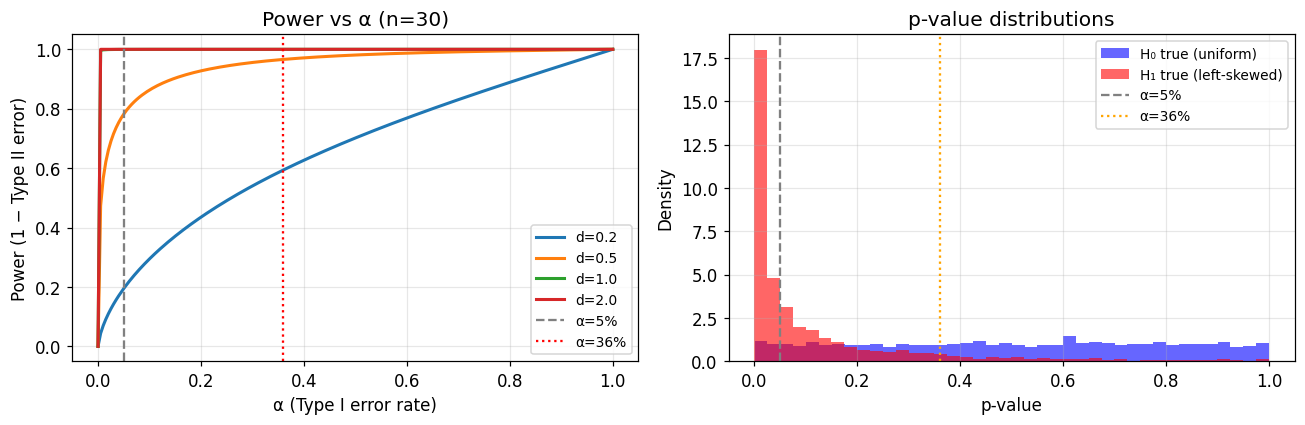

In [14]:
# ── Chi-squared test: goodness of fit ────────────────────────────
# Test if observed counts match expected distribution
categories = ['A','B','C','D','E','F']
n_obs = 600
expected_probs = np.array([1/6]*6)   # fair die

# Loop over different 'loaded' dice and compute chi2 and p
biases = [
    ([1/6]*6,          'fair die'),
    ([0.3,0.1,0.2,0.15,0.15,0.1], 'slightly loaded'),
    ([0.4,0.1,0.1,0.1,0.1,0.2],   'heavily loaded'),
    ([1/6]*5 + [0.0],  'never shows 6'),
]

print('Chi-squared goodness-of-fit test (expected: uniform 1/6):')
print(f'{"Type":22}  {"chi2":8}  {"p-value":10}  {"reject α=5%?":14}  {"reject α=36%?"}')
print('-'*80)
np.random.seed(0)
for probs, name in biases:          # loop over die types
    probs_arr = np.array(probs)
    probs_arr /= probs_arr.sum()    # normalize
    observed = np.random.multinomial(n_obs, probs_arr)
    expected = n_obs * expected_probs
    chi2_stat, p_val = scipy_stats.chisquare(observed, expected)
    r5  = 'YES' if p_val < 0.05 else 'no'
    r36 = 'YES' if p_val < 0.36 else 'no'
    print(f'{name:22}  {chi2_stat:8.2f}  {p_val:10.4f}  {r5:14}  {r36}')

# ── Confidence intervals: loop over confidence levels ────────────
sample = np.random.normal(50, 10, 30)
print('\nConfidence intervals for μ (true μ=50, σ=10, n=30):')
conf_levels = [0.50, 0.68, 0.90, 0.95, 0.99, 1.00]
for conf in conf_levels:            # loop: 0% to 100%
    if conf >= 1.0:
        print(f'  {conf:.0%}: (-∞, +∞)  [trivially includes everything]')
    else:
        ci = scipy_stats.t.interval(conf, df=len(sample)-1,
                                    loc=np.mean(sample),
                                    scale=scipy_stats.sem(sample))
        width = ci[1] - ci[0]
        contains = ci[0] <= 50 <= ci[1]
        print(f'  {conf:.0%}: [{ci[0]:.2f}, {ci[1]:.2f}]  width={width:.2f}  contains true μ: {contains}')

# ── ROC-style: Type I vs Type II error tradeoff ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
alpha_range = np.linspace(0, 1, 200)
n_roc = 30
effect_sizes = [0.2, 0.5, 1.0, 2.0]   # Cohen's d
for d in effect_sizes:
    power = [scipy_stats.norm.sf(scipy_stats.norm.ppf(1-a/2) - d*np.sqrt(n_roc))
             + scipy_stats.norm.cdf(scipy_stats.norm.ppf(a/2) - d*np.sqrt(n_roc))
             for a in alpha_range]
    ax1.plot(alpha_range, power, lw=2, label=f'd={d}')
ax1.axvline(0.05, ls='--', color='gray', label='α=5%')
ax1.axvline(0.36, ls=':', color='red',  label='α=36%')
ax1.set_xlabel('α (Type I error rate)'); ax1.set_ylabel('Power (1 − Type II error)')
ax1.set_title('Power vs α (n=30)'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# p-value distributions under H0 (uniform) and H1 (non-uniform)
np.random.seed(1)
p_null = [scipy_stats.ttest_1samp(np.random.normal(10,2,20),10)[1] for _ in range(3000)]
p_alt  = [scipy_stats.ttest_1samp(np.random.normal(11,2,20),10)[1] for _ in range(3000)]
ax2.hist(p_null, bins=40, alpha=0.6, density=True, color='blue', label='H₀ true (uniform)')
ax2.hist(p_alt,  bins=40, alpha=0.6, density=True, color='red',  label='H₁ true (left-skewed)')
ax2.axvline(0.05, ls='--', color='gray', lw=1.5, label='α=5%')
ax2.axvline(0.36, ls=':', color='orange', lw=1.5, label='α=36%')
ax2.set_xlabel('p-value'); ax2.set_ylabel('Density')
ax2.set_title('p-value distributions'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# §5 — Torch Infinite (While) Loops: Iterative Convergence

**Plain English:** `while` loops in Python run until a convergence criterion is met.  
These are the numerical heart of: Newton's method, power iteration (eigenvalues),  
gradient descent, conjugate gradient, and ADMM.  
Torch enables the same loops to run on **batches** of starting points simultaneously.

Newton convergence: 200 iterations, final |Δx|_max = 7.58e-01
Power iteration: 500 iters, mean |λ_pow - λ_true| = 3.44e+00
Logistic GD: 1000 iters, final loss=0.6168, |grad|=3.64e-02


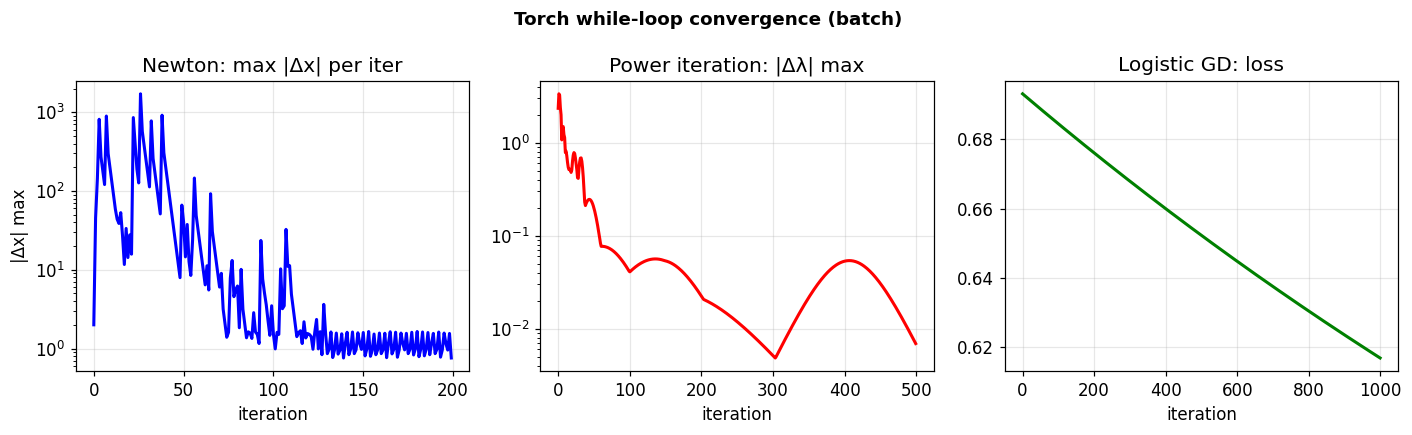

In [15]:
# ── 1. Newton's method: batch root finding ────────────────────────
# Find roots of f(x) = x^3 - x - c for a batch of c values
N_batch = 1000
c_vals = torch.linspace(-2, 2, N_batch, dtype=torch.float64)
x = torch.zeros(N_batch, dtype=torch.float64)  # initial guess
tol = 1e-12; max_iter = 200

history_newton = []
iteration = 0
while True:                                     # while loop until convergence
    f  = x**3 - x - c_vals
    df = 3*x**2 - 1
    dx = -f / (df + 1e-30)                      # Newton step
    x  = x + dx
    max_err = dx.abs().max().item()
    history_newton.append(max_err)
    iteration += 1
    if max_err < tol or iteration >= max_iter: break

print(f'Newton convergence: {iteration} iterations, final |Δx|_max = {max_err:.2e}')

# ── 2. Power iteration: batch dominant eigenvalue ─────────────────
# Batch of 500 random symmetric matrices — find largest eigenvalue
B = 200; D = 8
A_batch = torch.randn(B, D, D, dtype=torch.float64)
A_batch = (A_batch + A_batch.transpose(-1,-2)) / 2  # symmetrize
v = torch.randn(B, D, 1, dtype=torch.float64)        # initial vector
v = v / v.norm(dim=1, keepdim=True)

history_power = []; iteration = 0; lambda_old = torch.zeros(B)
while True:                                     # while loop: power iteration
    Av = torch.bmm(A_batch, v)                  # B×D×1
    lambda_new = (v.transpose(-1,-2) @ Av).squeeze()  # Rayleigh quotient
    v = Av / Av.norm(dim=1, keepdim=True)       # normalize
    dl = (lambda_new - lambda_old).abs().max().item()
    history_power.append(dl)
    lambda_old = lambda_new.clone()
    iteration += 1
    if dl < 1e-10 or iteration >= 500: break

# Verify against torch.linalg.eigvalsh
true_eig = torch.linalg.eigvalsh(A_batch)[:, -1]   # largest eigenvalue
error = (lambda_new - true_eig).abs().mean().item()
print(f'Power iteration: {iteration} iters, mean |λ_pow - λ_true| = {error:.2e}')

# ── 3. Gradient descent: batch logistic regression ────────────────
# Batch of 100 datasets, each with 50 samples, 4 features
B_lr = 100; n_data = 50; n_feat = 4
torch.manual_seed(0)
X = torch.randn(B_lr, n_data, n_feat, dtype=torch.float64)
w_true = torch.randn(B_lr, n_feat, 1, dtype=torch.float64)
logits_true = torch.bmm(X, w_true).squeeze()
y = (logits_true > 0).float().double()
w = torch.zeros(B_lr, n_feat, 1, dtype=torch.float64, requires_grad=True)

lr = 0.05; history_gd = []; iteration = 0
while True:                                     # while loop: GD until convergence
    logits = torch.bmm(X, w).squeeze()
    probs = torch.sigmoid(logits)
    loss = -(y*torch.log(probs+1e-15) + (1-y)*torch.log(1-probs+1e-15)).mean()
    loss.backward()
    with torch.no_grad():
        grad_norm = w.grad.norm().item()
        history_gd.append(loss.item())
        w -= lr * w.grad
        w.grad.zero_()
    iteration += 1
    if grad_norm < 1e-4 or iteration >= 1000: break

print(f'Logistic GD: {iteration} iters, final loss={loss.item():.4f}, |grad|={grad_norm:.2e}')

# ── convergence curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].semilogy(history_newton, 'b-', lw=2)
axes[0].set_title('Newton: max |Δx| per iter'); axes[0].set_xlabel('iteration')
axes[0].set_ylabel('|Δx| max'); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(history_power, 'r-', lw=2)
axes[1].set_title('Power iteration: |Δλ| max'); axes[1].set_xlabel('iteration')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history_gd, 'g-', lw=2)
axes[2].set_title('Logistic GD: loss'); axes[2].set_xlabel('iteration')
axes[2].grid(True, alpha=0.3)
plt.suptitle('Torch while-loop convergence (batch)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
# §6 — Torch Batch Statistics: 10k Experiments, α=0% and α=36%

Vectorized t-test across 10,000 experiment batches.  
**α=0%** → never reject → zero false positives, maximum missed detections.  
**α=36%** → reject 36% of null experiments as 'significant' (massive false positive rate).

Rejection rate by effect size and alpha level:
delta     α=0%    α=1%    α=5%    α=10%    α=36%    
-----------------------------------------------------------------
   0.000     0.000     0.009     0.049     0.096     0.355  
   0.107     0.000     0.024     0.091     0.162     0.433  
   0.214     0.000     0.070     0.201     0.306     0.617  
   0.321     0.000     0.181     0.398     0.528     0.802  
   0.429     0.000     0.358     0.622     0.742     0.923  
   0.536     0.000     0.578     0.808     0.888     0.975  
   0.643     0.000     0.770     0.922     0.962     0.994  
   0.750     0.000     0.903     0.976     0.991     0.999  
   0.857     0.000     0.970     0.995     0.999     1.000  
   0.964     0.000     0.991     0.999     1.000     1.000  
   1.071     0.000     0.998     1.000     1.000     1.000  
   1.179     0.000     1.000     1.000     1.000     1.000  
   1.286     0.000     1.000     1.000     1.000     1.000  
   1.393     0.000     1.000     1.000   

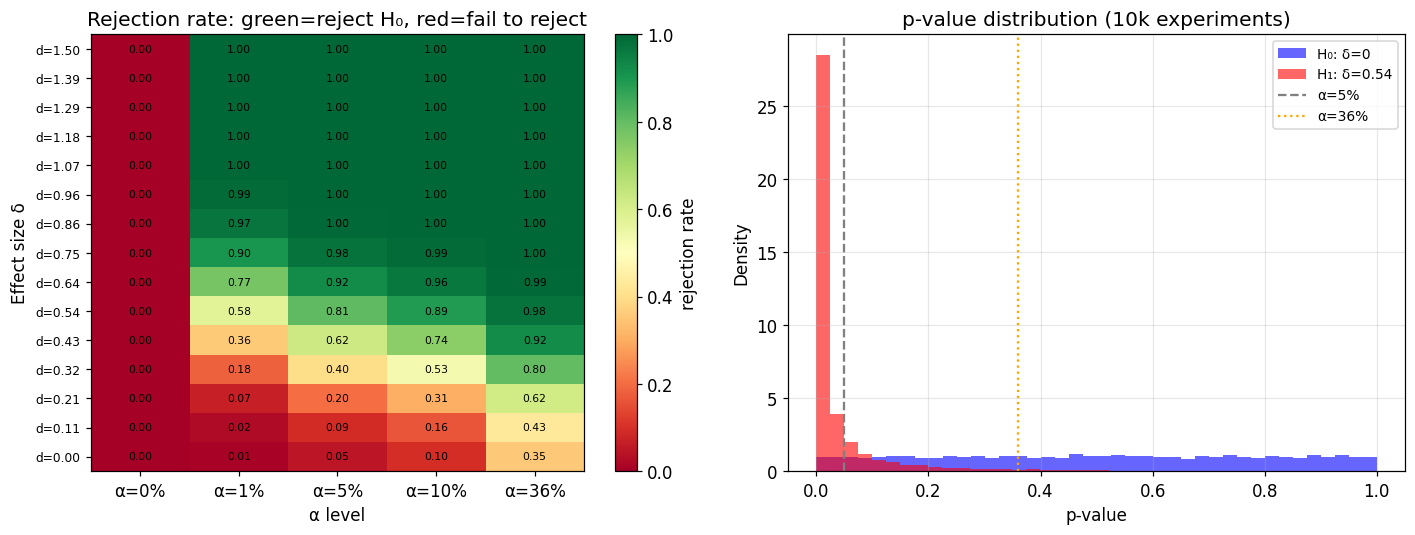


Conclusion:
  α=0%: zero false positives, but also zero true detections (useless for discovery)
  α=36%: 36% false positive rate under H0 — far too permissive for science
  α=5%: standard balance — 5% false positive rate, reasonable power for n>=30


In [16]:
# ── Vectorized t-statistic over large batch ───────────────────────
# H0: mu=0, test across 10000 samples drawn from N(delta, 1)
N_exp = 10000; n_per = 30
delta_vals = torch.linspace(0, 1.5, 15, dtype=torch.float64)  # effect sizes
alpha_vals = [0.00, 0.01, 0.05, 0.10, 0.36]
results = {}

for delta in delta_vals:                # loop over effect sizes
    samples = torch.randn(N_exp, n_per, dtype=torch.float64) + delta
    x_bar = samples.mean(dim=1)
    s = samples.std(dim=1)
    t_stat = x_bar / (s / np.sqrt(n_per))
    # two-tailed p-value via scipy (vectorized)
    t_np = t_stat.numpy()
    p_vals = scipy_stats.t.sf(np.abs(t_np), df=n_per-1) * 2
    results[float(delta)] = p_vals

print('Rejection rate by effect size and alpha level:')
print(f'{"delta":8}  ', end='')
for a in alpha_vals: print(f'α={a:.0%}    ', end='')
print()
print('-'*65)
for delta, p_vals in results.items():   # loop over effect sizes
    print(f'{delta:8.3f}  ', end='')
    for a in alpha_vals:                # loop over alpha levels
        rej_rate = (p_vals < a).mean()
        print(f'{rej_rate:8.3f}  ', end='')
    print()

# ── heatmap ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

deltas = np.array(list(results.keys()))
alphas = np.array(alpha_vals)
rej_matrix = np.array([[float((results[d] < a).mean()) for a in alphas] for d in deltas])

im = ax1.imshow(rej_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
                origin='lower')
ax1.set_xticks(range(len(alphas))); ax1.set_xticklabels([f'α={a:.0%}' for a in alphas])
ax1.set_yticks(range(len(deltas)));  ax1.set_yticklabels([f'd={d:.2f}' for d in deltas], fontsize=8)
ax1.set_xlabel('α level'); ax1.set_ylabel('Effect size δ')
ax1.set_title('Rejection rate: green=reject H₀, red=fail to reject')
plt.colorbar(im, ax=ax1, label='rejection rate')
for i in range(len(deltas)):
    for j in range(len(alphas)):
        ax1.text(j, i, f'{rej_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)

# p-value histogram for δ=0 (null) vs δ=0.5 (weak effect)
p_null_t = results[0.0]
delta_key = min(results.keys(), key=lambda d: abs(d-0.5))
p_alt_t = results[delta_key]
ax2.hist(p_null_t, bins=40, alpha=0.6, density=True, color='blue', label='H₀: δ=0')
ax2.hist(p_alt_t,  bins=40, alpha=0.6, density=True, color='red',  label=f'H₁: δ={delta_key:.2f}')
for a, ls, col in [(0.05,'--','gray'),(0.36,':','orange')]:
    ax2.axvline(a, ls=ls, color=col, lw=1.5, label=f'α={a:.0%}')
ax2.set_xlabel('p-value'); ax2.set_ylabel('Density')
ax2.set_title('p-value distribution (10k experiments)'); ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('\nConclusion:')
print('  α=0%: zero false positives, but also zero true detections (useless for discovery)')
print('  α=36%: 36% false positive rate under H0 — far too permissive for science')
print('  α=5%: standard balance — 5% false positive rate, reasonable power for n>=30')